# Installation PyPSA-Eur

This notebook walks through the full PyPSA-Eur workflow: setup, running the model, and analysing results from a solved sector-coupled network.

## Part 1 - Setup & running the workflow

### 1.1 Install Pixi (package manager)

```bash
curl -fsSL https://pixi.sh/install.sh | bash
source ~/.bashrc  # or restart terminal
```

### 1.2 Clone PyPSA-Eur

```bash
git clone https://github.com/PyPSA/pypsa-eur.git
cd pypsa-eur
```

### 1.3 Install the environment

```bash
pixi install
```

Reads `pixi.toml` and installs all dependencies into `.pixi/envs/default/`. Takes a few minutes on first run.

### 1.4 Configure

```bash
cp config/config.default.yaml config/config.yaml
```

Edit `config/config.yaml` to set countries, number of clusters, time horizon, etc.

### 1.5 Run the workflow

```bash
pixi run snakemake -c all all -j 4
```

Resume after a crash:

```bash
pixi run snakemake -c all all -j 4 --rerun-incomplete
```

### 1.6 Install PyPSA

The PyPSA to GEMS converter is fit to v1.0.0 PyPSA, so we need this version

```bash
pip install pypsa == 1.0.0
```

## Part 2 - Loading the network

Results are stored as NetCDF files under `pypsa-eur/results/networks/`.
The filename encodes the configuration: `base_s_***.nc`

In [1]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

n = pypsa.Network("pypsa-eur/resources/networks/base_s_1_elec.nc")
print(n)

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.0.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks


PyPSA Network 'Unnamed Network'


# Conversion to GEMS format

## Part 3 - Install the converter 

### 3.1 Clone the converter repo
```bash
git clone https://github.com/AntaresSimulatorTeam/PyPSA-to-GEMS-Converter
```

## Part 4 - Imports & Logging

In [2]:
import sys                                                                                                                                                                                  
sys.path.insert(0, "PyPSA-to-GEMS-Converter")

from src import PyPSAStudyConverter
import logging
from pathlib import Path
import pypsa
from pypsa import Network


# Configure logging so progress is visible in the notebook
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s – %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("pypsa_to_gems")

# Check PyPSA version
print(f"PyPSA version : {pypsa.__version__}")

study_dir = Path("tmp/my_study")  # Absolute path to the GEMS study directory

PyPSA_file_path = "pypsa-eur/resources/networks/base_s_1_elec.nc"  # Absolute path to the PyPSA file
network = Network(PyPSA_file_path)
print(network)  # Print the network to verify it loaded correctly

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.0.0)


PyPSA version : 1.0.0


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, stores, sub_networks


PyPSA Network 'Unnamed Network'


## Part 5 - Conversion PYPSA network to GEMS

In [3]:
# Convert PyPSA network to GEMS
converter = PyPSAStudyConverter(
    pypsa_network=network,
    logger=logger,
    study_dir=study_dir,
    series_file_format=".tsv",  # Supported formats: .tsv, .csv
).to_gems_study()

INFO:pypsa_to_gems:Study conversion started
INFO:pypsa_to_gems:Copying library yml file to study directory
INFO:src.gems_model_builder:Creating objects of type: generator. 
INFO:src.gems_model_builder:Creating objects of type: load. 
INFO:src.gems_model_builder:Creating objects of type: bus. 
INFO:src.gems_model_builder:Creating objects of type: link. 
INFO:src.gems_model_builder:Creating objects of type: storage_unit. 
INFO:src.gems_model_builder:Creating objects of type: store. 
INFO:pypsa_to_gems:Study conversion completed!


## Part 6 - Inspect the GEMS Study

In [4]:
import yaml
from collections import defaultdict

gems_study_file_path = Path(study_dir) / "systems" / "input"

system_yml_files = list(gems_study_file_path.rglob("system.yml"))
if not system_yml_files:
    print("system.yml not found.")
else:
    data = yaml.safe_load(system_yml_files[0].read_text())["system"]

    components = data.get("components", [])
    connections = data.get("connections", [])

    # Group components by model type
    by_model = defaultdict(list)
    for c in components:
        by_model[c["model"]].append(c["id"])

    print(f"System : {data['id']}")
    print(f"\nComponents ({len(components)} total)")
    print("-" * 20)
    for model, ids in sorted(by_model.items()):
        short = model.split(".")[-1]
        print(f"  [{short}]  ({len(ids)})")
        for cid in ids:
            print(f"    - {cid}")

    print(f"\nConnections ({len(connections)} total)")
    print("-" * 20)
    for conn in connections:
        print(f"  {conn.get('component1')}.{conn.get('port1')}  →  {conn.get('component2')}.{conn.get('port2')}")

System : Unnamed Network

Components (27 total)
--------------------
  [bus]  (3)
    - FR0_0
    - FR0_0_H2
    - FR0_0_battery
  [generator]  (15)
    - generator_FR0_0_CCGT
    - generator_FR0_0_biomass
    - generator_FR0_0_coal
    - generator_FR0_0_geothermal
    - generator_FR0_0_lignite
    - generator_FR0_0_nuclear
    - generator_FR0_0_oil
    - generator_FR0_0_waste
    - generator_FR0_0_0_offwind-float
    - generator_FR0_0_0_offwind-ac
    - generator_FR0_0_0_onwind
    - generator_FR0_0_0_solar-hsat
    - generator_FR0_0_0_solar
    - generator_FR0_0_0_offwind-dc
    - generator_FR0_0_ror
  [link]  (4)
    - link_FR0_0_H2_Electrolysis
    - link_FR0_0_H2_Fuel_Cell
    - link_FR0_0_battery_charger
    - link_FR0_0_battery_discharger
  [load]  (1)
    - load_FR0_0
  [storage_unit]  (2)
    - storage_unit_FR0_0_PHS
    - storage_unit_FR0_0_hydro
  [store]  (2)
    - store_FR0_0_H2
    - store_FR0_0_battery

Connections (28 total)
--------------------
  FR0_0.p_balance_port  

## Part 6 - Run the GEMS optimization

In [5]:
# Path to the Antares modeler binary
from asyncio import subprocess
from subprocess import run as sp_run 

import shutil
modeler_bin = Path(shutil.which("antares-modeler") or "/usr/local/bin/antares-modeler")
#/home/gmaistre/rte/antares-9.3.6-Ubuntu-22.04/bin # Absolute path to the Antares modeler binary                                                                                         
                                                            
sp_run([
      str(modeler_bin),
      str(study_dir / "systems")
  ])

[2026-04-27 17:15:29][modeler][infos] Study path: tmp/my_study/systems
[2026-04-27 17:15:29][modeler][infos] Parameters loaded
[2026-04-27 17:15:29][modeler][infos] Loading modeler files...
[2026-04-27 17:15:29][modeler][infos] Optim config file not found at tmp/my_study/systems/input/optim-config.yml
[2026-04-27 17:15:29][modeler][infos] Library loaded: pypsa_models
[2026-04-27 17:15:29][modeler][infos] Libraries loaded
[2026-04-27 17:15:29][modeler][infos] System loaded
[2026-04-27 17:15:29][modeler][infos] Data-series loaded
[2026-04-27 17:15:29][modeler][infos] Timeseries loaded
[2026-04-27 17:15:29][modeler][infos] No scenario builder found, skipping scenario groups loading.
[2026-04-27 17:15:29][modeler][infos] Scenario groups loaded
[2026-04-27 17:15:29][modeler][infos] Modeler loaded in 0.017 s
[2026-04-27 17:15:29][modeler][infos] Locations validity OK
[2026-04-27 17:15:29][modeler][infos] linear problem of System loaded
[2026-04-27 17:15:29][modeler][infos] Linear problem pro

CompletedProcess(args=['/usr/bin/antares-modeler', 'tmp/my_study/systems'], returncode=0)

## Part 7 - Analyse the simulation results

The solver writes a `simulation_table--<timestamp>.csv` file under `systems/output/`.  
Below we load the most recent one and visualise:
- the **objective value** (total system cost)
- the **installed capacity** (`p_nom`) per generator technology
- the **dispatch** (`p`) time series per technology

Reading: tmp/my_study/systems/output/simulation_table--20260427-1715.csv

Objective value (total system cost): 86,300,015 €


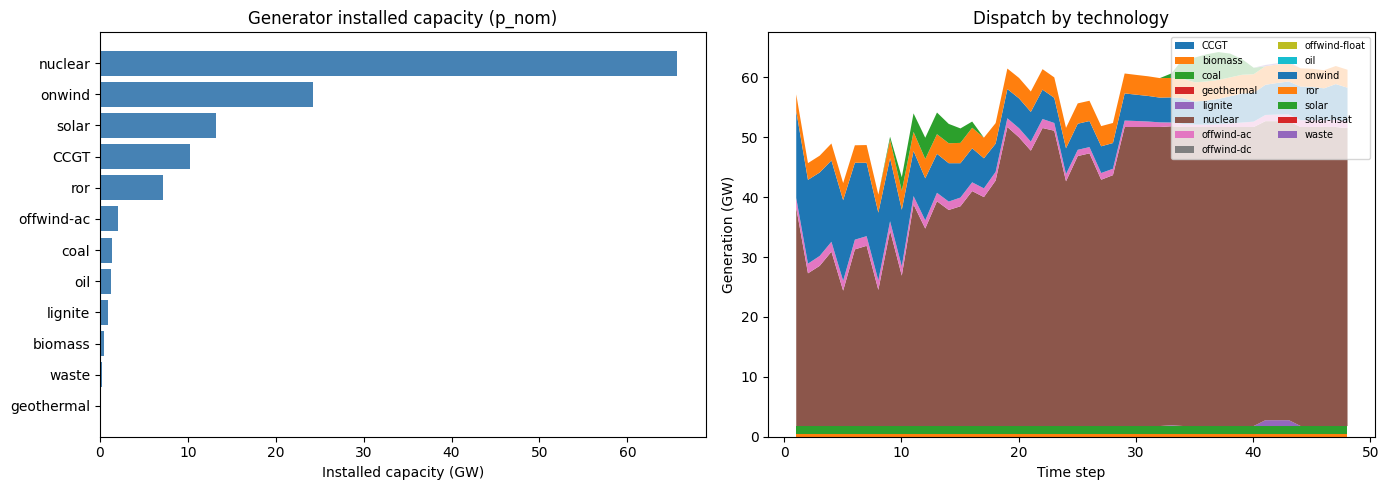

In [6]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ── Load the most recent simulation table ──────────────────────────────────────
output_dir = study_dir / "systems" / "output"
csv_files = sorted(glob.glob(str(output_dir / "simulation_table--*.csv")))
assert csv_files, f"No simulation_table CSV found in {output_dir}"
sim_csv = csv_files[-1]
print(f"Reading: {sim_csv}")

df = pd.read_csv(sim_csv)

# ── Objective value ────────────────────────────────────────────────────────────
obj_row = df[df["output"] == "OBJECTIVE_VALUE"]
if not obj_row.empty:
    obj_value = obj_row["value"].iloc[0]
    print(f"\nObjective value (total system cost): {obj_value:,.0f} €")

# ── Installed capacity (p_nom) per generator technology ───────────────────────
p_nom_df = df[
    (df["output"] == "p_nom") &
    (df["component"].str.startswith("generator_", na=False))
].copy()

# Extract technology name: last segment after the final "_"
p_nom_df["technology"] = p_nom_df["component"].str.split("_").str[-1]
capacity = p_nom_df.groupby("technology")["value"].sum().sort_values(ascending=False)
capacity = capacity[capacity > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(capacity.index, capacity.values / 1e3, color="steelblue")
axes[0].set_xlabel("Installed capacity (GW)")
axes[0].set_title("Generator installed capacity (p_nom)")
axes[0].invert_yaxis()

# ── Dispatch time series (p) per technology ───────────────────────────────────
p_df = df[
    (df["output"] == "p") &
    (df["component"].str.startswith("generator_", na=False)) &
    (df["absolute_time_index"].notna())
].copy()

p_df["technology"] = p_df["component"].str.split("_").str[-1]
p_df["t"] = pd.to_numeric(p_df["absolute_time_index"])

dispatch = (
    p_df.groupby(["t", "technology"])["value"]
    .sum()
    .unstack("technology")
    .fillna(0)
    .clip(lower=0)          # ignore small negative solver artefacts
)
dispatch = dispatch / 1e3   # MW → GW

dispatch.plot.area(ax=axes[1], linewidth=0)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Generation (GW)")
axes[1].set_title("Dispatch by technology")
axes[1].legend(loc="upper right", fontsize=7, ncol=2)

plt.tight_layout()
plt.show()